## Step 0 – Setup & Imports

**Why this step matters:**  
Before building any ML model, we prepare the environment by importing essential tools and setting a random seed. This ensures our workflow is reproducible and organized.

### 🔑 Key Functions Explained

- **np.random.seed(42)**  
  - **What it does:** Fixes the random number generator.  
  - **Why we use it:** Makes random operations (like data splits or model initialization) produce the same results each time.  
  - **Why it matters in ML:** Ensures experiments are reproducible and results are consistent.

- **load_breast_cancer**  
  - **What it does:** Loads a ready-to-use binary classification dataset.  
  - **Why we use it:** Allows quick testing of ML pipelines without needing external data.  
  - **Why it matters in ML:** Great for learning and prototyping without data-cleaning overhead.

- **train_test_split**  
  - **What it does:** Splits data into training and test sets.  
  - **Why we use it:** To train the model on one part and test it on unseen data.  
  - **Why it matters in ML:** Prevents overfitting and gives a realistic measure of model performance.

- **StandardScaler**  
  - **What it does:** Standardizes features to have mean 0 and variance 1.  
  - **Why we use it:** Many ML models perform better when features are on the same scale.  
  - **Why it matters in ML:** Improves convergence speed and model accuracy, especially for linear models.

- **Pipeline**  
  - **What it does:** Chains preprocessing and modeling steps into one object.  
  - **Why we use it:** Keeps workflows clean, reduces errors, and simplifies cross-validation.  
  - **Why it matters in ML:** Ensures the same preprocessing is applied consistently during training and prediction.

- **LogisticRegression**  
  - **What it does:** A linear model for binary classification.  
  - **Why we use it:** Acts as a strong, interpretable baseline.  
  - **Why it matters in ML:** Helps us understand performance benchmarks before trying more complex models.

- **RandomForestClassifier**  
  - **What it does:** An ensemble of decision trees for classification.  
  - **Why we use it:** Captures non-linear patterns and interactions automatically.  
  - **Why it matters in ML:** Often improves accuracy and robustness compared to linear models.

- **accuracy_score / roc_auc_score**  
  - **What they do:** Measure how well the model predicts correctly (`accuracy`) and how well it ranks positive vs. negative cases (`roc_auc`).  
  - **Why we use them:** To evaluate model quality from different perspectives.  
  - **Why they matter in ML:** Choosing the right metrics ensures we understand a model’s strengths and weaknesses.


In [ ]:
# -------- Step 0: Setup (every line commented) --------
import numpy as np                  # arrays, small math helpers
import pandas as pd                # tabular inspection (optional but handy)

# scikit-learn building blocks
from sklearn.datasets import load_breast_cancer     # toy dataset
# Cross-val_score: it's a function that performs cross-validation that is a process of evaluating a model's 
# performance by splitting the data into multiple folds and training and testing the model on each fold.
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler    # feature scaling
from sklearn.pipeline import Pipeline, make_pipeline # chain steps cleanly
from sklearn.linear_model import LogisticRegression # baseline linear classifier
from sklearn.ensemble import RandomForestClassifier # non-linear ensemble
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix



# Why seed = 42? 
# Seed means the starting point for the random number generator.
# It's a convention to use 42 as the seed value.
# It's a popular choice in the ML community.
# It's like a magic number! :)
RANDOM_STATE = 42                  # reproducibility for splits and models 
np.random.seed(RANDOM_STATE)       # set global seed (not strictly required)


## Step 1 – Data Loading

**Goal:**   
The first step in any machine learning project is to load the dataset into memory. Here, we use a built-in breast cancer dataset from scikit-learn. Our goal is to separate the data into **features (`X`)** and **labels (`y`)**.  
- **Features (`X`)** are the measurable properties or inputs we use to train the model — for example, tumor characteristics such as size, texture, or smoothness. Each row in `X` represents one patient, and each column is one property measured about that patient.  
- **Labels (`y`)** are what we want the model to predict — in this case, whether the tumor is malignant (`0`) or benign (`1`).  
We will also convert the feature matrix into a Pandas DataFrame for easier viewing and quick 
exploration.


*Why this step matters:**  
Before training any model, we need to load our dataset into memory. This step gives us the feature matrix `X` and label vector `y`, which are the core inputs for all machine learning workflows.

### 🔑 Key Function

- **load_breast_cancer()**  
  - **What it does:** Loads a built-in breast cancer dataset as a `Bunch` object (similar to a dictionary).  
  - **Why we use it:** It gives us ready-made data with `.data` for features, `.target` for labels, and `.feature_names` for column names — perfect for quick experiments.  
  - **Why it matters in ML:** Provides structured input data without needing manual data collection or cleaning, letting us focus on learning the pipeline.
  - In ML, `Bunch` means...? In machine learning, specifically within the Scikit-learn library, a Bunch is a container object that functions like a dictionary but also allows its keys to be accessed as object attributes using dot notation. It is often used to hold and organize datasets returned by Scikit-learn's built-in functions. 


We then separate:
- `X`: a NumPy array containing feature values for each sample.  
- `y`: binary labels (`0` or `1`) indicating the target class.  
- `feature_names`: column names for readability and inspection.  

Creating a `DataFrame` from `X` with `feature_names` makes it easier to explore and understand the dataset before modeling.


In [ ]:
# -------- Step 1: Load data --------
data_bunch = load_breast_cancer()                  # load dataset into a Bunch
X = data_bunch.data                                # numpy array of shape (n_samples, n_features)
y = data_bunch.target                              # binary labels (0/1) it means malignant or benign
feature_names = data_bunch.feature_names            # names for columns (optional)
df = pd.DataFrame(X, columns=feature_names)         # nice for quick peeks
print(df.shape, np.bincount(y))                     # (rows, cols) and class counts


print ("Dataset example as table:")
print (df.head())



(569, 30) [212 357]
Dataset example as table:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  

## Step 2 – Train/Test Split

**Goal:**  
Now that we have our features `X` and labels `y`, the next step is to split the data into two parts: a **training set** and a **test set**. The training set is used to teach the model how to find patterns, while the test set is kept completely separate and used **only at the end** to evaluate how well the model generalizes to new, unseen data.  
For example, if `X` contains tumor features like size and smoothness, and `y` tells us whether each tumor is malignant or benign, we train the model on most of this data and then test it on the remaining part to see if it predicts new cases correctly.

**Why this step matters:**  
Without a separate test set, we might build a model that performs well on the data it’s seen but fails on new data. A clean train/test split gives us an honest estimate of real-world performance.

### 🔑 Key Function

- **train_test_split(X, y, test_size, random_state, stratify)**  
  - **What it does:** Splits the dataset into training and testing sets.  
  - **Why we use it:** Ensures we have data for both model training and independent evaluation.  
  - **Why it matters in ML:** Prevents overfitting and helps us measure how well the model generalizes.  
  - **Important parameters:**  
    - `test_size=0.2`: Keeps 20% for testing and 80% for training.  
    - `random_state`: Makes the split reproducible.  
    - `stratify=y`: Preserves the class distribution in both sets, which is especially important for imbalanced datasets.

After splitting, we get:  
- `X_train`, `y_train`: Data the model learns from.  
- `X_test`, `y_test`: Data for final evaluation.  
We also print their shapes to verify the split.

In [ ]:
# -------- Step 2: Split data --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                      # inputs and labels
    test_size=0.2,             # 80/20 split
    random_state=RANDOM_STATE, # we need to set a random state to make the split reproducible
    stratify=y                 # keep class balance the same in both sets
)
print(X_train.shape, X_test.shape)


(455, 30) (114, 30)


## Step 3 – Data Preparation (Scaling) with a Pipeline

**Goal:**  
Before training, we prepare our features so the model can learn effectively. Many machine learning algorithms, like logistic regression, assume features are on a similar scale. For example, one feature might be tumor size measured in **millimeters (e.g., 20–150)**, while another might be texture measured from **0 to 1**. Without scaling, the model might give more weight to the “bigger number” feature just because of its scale, not because it’s more important.  
We use a **Pipeline** to chain the scaling and model training steps together, making sure scaling is done correctly — learned only from the training data and then applied to new data. This avoids **data leakage** and ensures consistent preprocessing throughout.

**What happens if we don’t use a pipeline:**  
If you scale the entire dataset **before** splitting, the scaler sees information from the test set. That means the model indirectly “knows” something about the test data during training, which leads to overly optimistic performance. Pipelines prevent this by automatically fitting the scaler only on the training set.

---

### 🔑 Key Functions

- **StandardScaler**  
  - **What it does:** Adjusts each feature so it has a mean of 0 and a standard deviation of 1.  
  - **Why we use it:** Ensures all features contribute equally to the model.  
  - **Why it matters in ML:** Helps models converge faster and improves accuracy, especially for algorithms that depend on feature magnitudes.

- **Pipeline(steps=[("name", transformer_or_model), ...])**  
  - **What it does:** Chains preprocessing and modeling steps into one object.  
  - **Why we use it:** Keeps the workflow clean and applies preprocessing correctly inside cross-validation and test evaluation.  
  - **Why it matters in ML:** Prevents data leakage and reduces human error.

📦 **Pipeline inputs explained:**  
- A pipeline takes a list of steps as tuples: `("step_name", transformer_or_estimator)`.  
- Each **step name** is a label you choose (e.g., `"scaler"`, `"clf"`).  
- Each **transformer or estimator** is an object that implements `.fit()` and optionally `.transform()` (for preprocessing) or `.predict()` (for models).  
- The steps run **in order**: data flows from the first transformer to the next, and finally into the model.

✅ Example:  
- Step 1: `"scaler"` uses `StandardScaler` to learn scaling from `X_train` and apply it to data.  
- Step 2: `"clf"` uses `LogisticRegression` to train on the scaled features.  

The final `logreg_pipe` object behaves like a single model — you can call `.fit()`, `.predict()`, and `.score()` on it directly.


In [8]:
# -------- Step 3: Build a baseline pipeline --------
logreg_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),             # fit scaler on X_train, transform X_train/X_test
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])


## Step 4 – Model Selection with Quick Cross-Validation

**Goal:**  
Now that we have our data ready and a baseline pipeline, the next step is to **choose the best model** to move forward with. Instead of training one model and trusting a single accuracy number, we use **cross-validation (CV)** — a method that splits the training data into several parts (called *folds*), trains and tests on different combinations, and gives us an **average performance score**.  
This gives a much more reliable picture of how a model will behave on new data. Here, we quickly compare two models: a **Logistic Regression** (linear) and a **Random Forest** (non-linear ensemble).

**Why this step matters:**  
Choosing a model without CV risks overfitting to a single train-test split. Cross-validation uses multiple splits to produce a stable, fair estimate of model performance — helping us choose the stronger model before tuning.

---

### 🔑 Key Functions

- **make_pipeline(StandardScaler(), LogisticRegression(...))**  
  - **What it does:** Creates a pipeline in one line instead of defining it step by step.  
  - **Why we use it:** Keeps model creation clean and readable, especially when trying multiple models.  
  - **Why it matters in ML:** Simplifies model comparison and ensures preprocessing is applied consistently.

- **cross_val_score(estimator, X, y, cv, scoring)**  
  - **What it does:** Runs cross-validation and returns a score (like accuracy or AUC) for each fold.  
  - **Why we use it:** Gives a more reliable measure of how the model will generalize.  
  - **Why it matters in ML:** Prevents misleading results from a single split and helps us compare models fairly.

- **KFold(n_splits, shuffle, random_state)**  
  - **What it does:** Defines how many folds to split the training data into (e.g., 5 splits).  
  - **Why we use it:** Ensures reproducible and randomized CV splits.  
  - **Why it matters in ML:** Avoids biased performance estimates and makes experiments consistent.

---

📊 **Example – Why CV is Better:**  
Imagine we train a model on 80% of the data and test it on the remaining 20%. If that 20% is “easy,” the model might look perfect but fail in real scenarios.  
Cross-validation fixes this by training and testing the model on **different slices** of the data multiple times — e.g., in 5-fold CV, the model trains on 80% and tests on 20% **five times**, each with different data. The average score is a more trustworthy performance estimate.

Here’s how it works in a typical 5-fold cross-validation:
- The training data is split into 5 equal parts (folds).
- In the first run, the model trains on folds 1-4 and tests on fold 5.
- In the second run, it trains on folds 1, 2, 3, 5 and tests on fold 4.
- This continues until every fold has been used once as the validation (test) part.

---

✅ After this step, we can compare the mean and standard deviation of AUC scores for each model. The one with higher and more stable performance is a better candidate for deeper tuning.

### 📈 Understanding Mean and Standard Deviation of AUC

- **Mean AUC:** The average performance across all folds. It shows how well the model performs overall.  
  ✅ Example: Scores `[0.88, 0.91, 0.89, 0.90, 0.92]` → mean ≈ **0.90** → strong overall performance.

- **Standard Deviation (std):** How much the scores vary between folds. Lower = more stable and consistent.  
  ✅ Example: std ≈ **0.014** means performance is similar across folds. If std ≈ **0.06**, the model is unstable.

👉 Best models have a **high mean** (good accuracy) and a **low std** (consistent results).


In [14]:
# -------- Step 4: Quick model comparison via CV --------
#KFold is a class that defines how to split the data into folds.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # 5-fold CV

logreg_cv_model = make_pipeline(StandardScaler(),
                                LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
rf_cv_model     = make_pipeline(StandardScaler(),               # scaler harmless for RF
                                RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))


# scoring can be "roc_auc" or "accuracy" or "f1" or "precision" or "recall"
logreg_scores = cross_val_score(logreg_cv_model, X_train, y_train, cv=cv, scoring="roc_auc")
rf_scores     = cross_val_score(rf_cv_model,     X_train, y_train, cv=cv, scoring="roc_auc")

print(f"LogReg AUC (mean±std): {logreg_scores.mean():.3f} ± {logreg_scores.std():.3f}")
print(f"RandForest AUC (mean±std): {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")





LogReg AUC (mean±std): 0.995 ± 0.007
RandForest AUC (mean±std): 0.990 ± 0.014


## Step 5 – Hyperparameter Tuning with GridSearchCV

**Goal:**  
After picking the stronger model, we try to make it even better by tuning its **hyperparameters** — the settings that control **how the model learns from data**. Unlike parameters (like weights in logistic regression) that the model learns automatically during training, **hyperparameters are chosen by us** before training and can drastically change performance.

For example, in a **Random Forest**:
- `n_estimators` – number of decision trees. More trees can improve performance but increase computation time.
- `max_depth` – how deep each tree can grow. Deeper trees capture more patterns but risk overfitting.
- `min_samples_split` – minimum samples needed to split a node. Higher values make trees simpler and reduce overfitting.
- `min_samples_leaf` – minimum samples required in a leaf node. Larger leaves make the model more general and stable.

By testing different combinations of these settings, we help the model find the **right balance between learning complex patterns and avoiding overfitting**.

---

### 🔑 Key Functions

- **GridSearchCV(estimator, param_grid, cv, scoring, n_jobs)**  
  - **What it does:** Tries all hyperparameter combinations, trains and evaluates each with cross-validation, and selects the best one.  
  - **Why we use it:** Automates the search for the best settings instead of manual trial and error.  
  - **Why it matters in ML:** Tuning can significantly boost model performance and generalization.

- **Pipeline parameter naming (`<step_name>__<param>`)**  
  - **What it does:** Allows us to tune parameters of a specific step inside a pipeline.  
  - **Example:** `"clf__n_estimators": [200, 400]` tunes the number of trees for the classifier step (`clf`).

📊 **Example:**  
If a random forest with `n_estimators=400` and `max_depth=10` achieves the highest AUC during cross-validation, `GridSearchCV` will return that combination as the best and automatically refit the pipeline on the full training set.

✅ After this step, `best_model` is a tuned version of our pipeline, optimized for better accuracy and stability.


In [ ]:
# -------- Step 5: Tune RandomForest inside a Pipeline --------
rf_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),                          # keeps API consistent
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE))
])

#param_grid is a dictionary of hyperparameters to tune.
param_grid = {
    "clf__n_estimators": [200, 400], # number of trees between 200 and 400
    "clf__max_depth": [None, 6, 10], # max depth of the tree between None and 10
    "clf__min_samples_split": [2, 5], # minimum samples needed to split a node between 2 and 5
    "clf__min_samples_leaf": [1, 2] # minimum samples required in a leaf node between 1 and 2
}

#GridSearchCV is a class that performs grid search with cross-validation.
#here grid is an object of GridSearchCV class.
grid = GridSearchCV( 
    estimator=rf_pipe,              # what to tune
    param_grid=param_grid,          # search space
    scoring="roc_auc",              # target metric
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1                       # use all cores
)

grid.fit(X_train, y_train)          # run the search
print("Best AUC (cv):", grid.best_score_)
print("Best params:", grid.best_params_)
best_model = grid.best_estimator_   # already refit on full training set


Best AUC (cv): 0.9909002818886539
Best params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 400}


## Step 6 – Final Fit, Evaluation, and Prediction

**Goal:**  
The final step is to test our tuned model on the **held-out test set** — the part of the data the model has never seen. This gives us the most honest estimate of how the model will perform on real-world, unseen data. We use the trained model to make predictions, calculate evaluation metrics, and even try a single new example.

**Why this step matters:**  
All previous steps used training data (with cross-validation). The test set is our final “reality check” — if the model performs well here, we can trust it to generalize.

---

### 🔑 Key Functions

- **predict_proba(X)[:, 1]**  
  - **What it does:** Returns the predicted probability of each sample being class 1 (e.g., benign tumor).  
  - **Why we use it:** Useful for threshold-free metrics like AUC that consider probability scores instead of fixed labels.

- **predict(X)**  
  - **What it does:** Returns hard class predictions (`0` or `1`).  
  - **Why we use it:** Needed for metrics like accuracy and confusion matrix.

- **roc_auc_score(y_true, y_proba)**  
  - **What it does:** Measures how well the model ranks positive vs. negative classes.  
  - **Why it matters:** AUC is robust and doesn’t depend on a specific probability cutoff.

- **accuracy_score(y_true, y_pred)**  
  - **What it does:** Percentage of correct predictions.  
  - **Why it matters:** A simple and intuitive metric for classification tasks.

- **classification_report(y_true, y_pred)**  
  - **What it does:** Shows precision, recall, and F1-score for each class.  
  - **Why it matters:** Gives a detailed breakdown of performance, not just a single number.

- **confusion_matrix(y_true, y_pred)**  
  - **What it does:** Counts true positives, true negatives, false positives, and false negatives.  
  - **Why it matters:** Helps understand the types of mistakes the model makes.

📊 **Example – Single Prediction:**  
We can also test the model on one new sample (e.g., the first row of `X_test`). `predict_proba()` tells us the probability it belongs to class 1, while `predict()` gives the final label.

✅ After this step, we know how well our model performs on unseen data and whether it’s ready for deployment.


In [ ]:
# In the previous step we have tuned the model and we have the best model.
# best_model = grid.best_estimator_  that passed the best parameters to the model.
# Now, the best_model is a pipeline that contains the best parameters.
# This pipeline is like a black box that contains the best parameters and the model.
# We can use this pipeline to predict the test set and evaluate the model.

# -------- Step 6: Evaluate on test set and predict --------
# Use best tuned model (from Step 5). If you skipped tuning, you can fall back to logreg_pipe.fit(...)
y_proba = best_model.predict_proba(X_test)[:, 1]    # probability of positive class
y_pred  = best_model.predict(X_test)                # hard predictions

test_auc  = roc_auc_score(y_test, y_proba)          # threshold-free metric
test_acc  = accuracy_score(y_test, y_pred)          # simple accuracy
print(f"Test AUC: {test_auc:.3f} | Test Accuracy: {test_acc:.3f}")

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

# Example: predict on a single new sample (take first row of test)
one_prob = best_model.predict_proba(X_test[:1])[:, 1][0]
one_pred = best_model.predict(X_test[:1])[0]
print(f"\nSingle-sample: prob={one_prob:.3f}, pred={one_pred}")


Test AUC: 0.993 | Test Accuracy: 0.956

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion matrix:
 [[39  3]
 [ 2 70]]

Single-sample: prob=0.000, pred=0


<Figure size 1000x700 with 0 Axes>

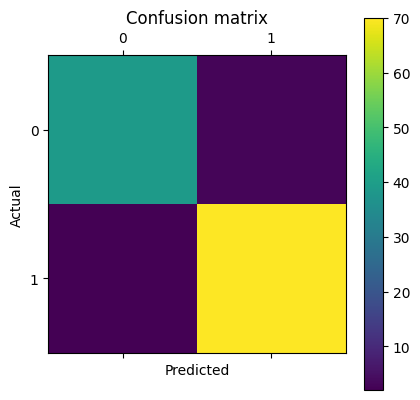

In [21]:
# print the confusion matrix

import matplotlib.pyplot
matplotlib.pyplot.figure(figsize=(10, 7))
matplotlib.pyplot.matshow(confusion_matrix(y_test, y_pred))
matplotlib.pyplot.title('Confusion matrix')
matplotlib.pyplot.colorbar()
matplotlib.pyplot.xlabel('Predicted')
matplotlib.pyplot.ylabel('Actual')
matplotlib.pyplot.show()